```{index} Statically indeterminate structures; Exam assignment
```
```{index} Continuum mechanics; Exam assignment
```
```{index} Buckling; Exam assignment
```

(exam4)=
# Exam Monday April 14th

Today you'll make the third exam assignment covering Statically indeterminate structures including its prerequisites and/or the third exam assignment covering Continuum mechanics including its prerequisites and/or the second exam assignment covering Buckling including its prerequisites. For more information about the exam see [the assessment information in course information](exam-general)

## Exam assignment 3 Statically indeterminate structures
Your own submission and its grading can be found here: [<img height="12px" src="../../figures/ANS.svg" alt="ANS"> exam assignment Statically indeterminate structures 3](https://ans.app/universities/1/courses/437261/assignments/1391318/go_to). The exam assignment was provided as follows:

Given is the structure as shown in the figure below.

```{figure} intro_data/SO.svg
:align: center
```

Calculate the normal force- and bending moment distribution using a force-, displacement- or hybrid- ('hoekveranderingsvergelijkingen' with moveable nodes) method.

````{admonition} Solution
:class: tip, dropdown

Convert the structure into a statically determinate structure with a displacement or force condition.

For example when using the force method:

```{figure} intro_data/SB.svg
:align: center
```

Using forget-me-nots, the displacement in A can be described as:


- $w_\text{A} = \cfrac{36}{25} - {24}{625} A_v $
- $u_\text{A} = 15 - \cfrac{3}{10} A_h$

With the requirements of no displacement, this results in:

- $A_v = -37.5 \text{ kN}$
- $A_h = -50 \text{ kN}$

This gives the normal force and bending moment distribution:

```{figure} intro_data/N-lijn.svg
:align: center
```

```{figure} intro_data/M-lijn.svg
:align: center
```
````

In [1]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_formats = ['svg']

L1, L2, L3, F, EI, EA = sym.symbols('L1 L2 L3 F EI EA', real=True, positive=True)

L1 = 4
L2 = 4
L3 = 2
F = 150
EI = sym.nsimplify(2500)
EA = sym.nsimplify(20)

Av, Ah = sym.symbols('Av Ah', real=True)

w_A = F * L3 * L2 **2 / EI / 2 / 2 + F * L3 * L2 / EI / 2 * L1 \
    - Av * (L2)**3 / EI / 2 / 3 - Av * L1 * L2**2 / EI / 2 / 2 \
    - L1 * ( Av * L2**2 / EI / 2 / 2 + Av * L1 * L2 / EI / 2) \
    - Av * L1 **3 / EI / 3
u_A = F * L2 / EA / 2 - Ah * L1 / EA - Ah * L2 / EA / 2

display(w_A, u_A)

sol = sym.solve([sym.Eq(w_A, 0), sym.Eq(u_A, 0)], (Av, Ah))
display(sol[Ah], sol[Av])


36/25 - 24*Av/625

15 - 3*Ah/10

50

75/2

## Exam assignment 3 Continuum mechanics

Your own submission and its grading will be available on [<img height="12px" src="../../figures/ANS.svg" alt="ANS"> exam assignment Continuum mechanics 2](https://ans.app/universities/1/courses/437261/assignments/1391075/go_to) after the exam.

Given is the following structure:

```{figure} intro_data/structure.svg
:align: center
```

- Find the stresses alongside all edges of the stress shown element from the point E in the cross-section just to the left of D in element CD.
- Evaluate whether the stress element fails according to Von Mises' failure criterium.

````{admonition} Solution
:class: tip, dropdown

In the cross-section, the bending moment is $0$. The normal force is $54 \text{ kN}$ and the shear force $72 \text{ kN}$

Relevant cross-sectional properties are:
- $A = 10800 \text{ mm}^2$
- From top fibre downwards, the normal force centre is at $200 \text{ mm}$
- $I_{zz} = 108043200 \text{ mm}^4$

This gives in E:
- $\sigma = 5 \text{ MPa}$
- $\tau \approx 10 \text{ MPa}$

The stresses on the stress element can be calculated using the transformation formulas or using Mohr

```{figure} intro_data/mohr.svg
:align: center
```

This leads to:
- $\sigma_1 = 12.8 \text{ MPa}$
- $\sigma_2 = -7.80 \text{ MPa}$

and the following stresses on the stress-element:

```{figure} intro_data/stress_state.svg
:align: center
```
The required yield stress results according to Von Mises is: $\sqrt{\cfrac{1}{2}\left( \left(12.8+7.8 \right)^2 + 12.8^2 + \left(-7.8\right)^2 \right) } = 12.7 \text{ MPa}$, so the point does not fail.

````

72

54.0000000000000

10800

100

108043200

...

0.0128038850912854

143.130102354156

-0.00639616153538585

0.00519888044782087

0.0127428439510817


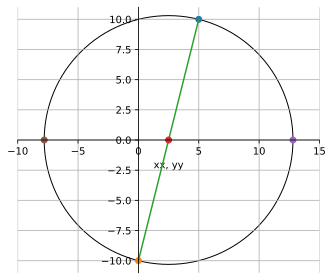

In [32]:
import sympy as sym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
%config InlineBackend.figure_formats = ['svg']

t, h, q, N, L, b, h_A = sym.symbols('t h q N L b h_A',real=True, positive=True)	

h = sym.nsimplify(300)
b = sym.nsimplify(300)
t = sym.nsimplify(12)
L = 6
q = sym.nsimplify(24)
#h_A = sym.nsimplify(50)

M =  q * L**2 / 8
V = q * L / 2
display(V)
N = V / 4 * 3
display(N.evalf())
tau = 0
A = b*t+h*t*2
display(A)
zc = h*t*2*h/2 / A
display(zc)
Izz = b * t**3 / 12 + b * t * zc**2 + 2 * t * h**3 / 12 + 2 * t * h * (zc - h/2)**2
display(Izz)
S_a = h * t * (h/2 - zc)
tau = V * (S_a) / t / Izz
sigma = N / A
print('tau, tau, sigma, sigma:')
display(tau)
display(tau.evalf())
display(sigma)
display(sigma.evalf())

sigma_min = ((sigma)/2-sym.sqrt(((-sigma)/2)**2+tau**2)).evalf()
sigma_max = ((sigma)/2+sym.sqrt(((-sigma)/2)**2+tau**2)).evalf()
display(sigma_min.evalf())
display(sigma_max.evalf())
#alpha_0 = sym.atan2(-tau,-sigma/2)/2
#display((alpha_0*180/sym.pi).evalf())
#print(np.rad2deg(alpha_tau))

#f_y = sym.sqrt(((sigma_max - sigma_min)**2 + sigma_max **2 + sigma_min**2)/2)
#display(f_y)
#f_y_2 = sym.sqrt(sigma**2 + 3 * tau**2)
#display(f_y_2)
#display(f_y_2.evalf())

#alpha = sym.pi  / 4
alpha = sym.atan2(3, -4)/sym.pi*180
#alpha = sym.pi*3/2
display(alpha.evalf())
alpha = sym.atan2(3, -4)
sigma_xx = sigma * sym.cos(alpha)**2 + 2 * tau * sym.sin(alpha) * sym.cos(alpha)
tau_xy = - sigma * sym.sin(alpha) * sym.cos(alpha) + tau * (- sym.sin(alpha)**2 + sym.cos(alpha)**2)
display(sigma_xx.evalf())
display(tau_xy.evalf())
#tau_xy = - sigma*sym.sin(alpha)*sym.cos(alpha)
#display(sigma_xx)
#display(tau_xy)
sigma_x = sigma*1000
sigma_y = 0
tau = tau*1000


plt.figure()
ax = plt.gca()
ax.set_aspect('equal')
ax.spines['right'].set_color('none')
ax.spines['bottom'].set_position('zero')
ax.spines['left'].set_position('zero')
ax.spines['top'].set_color('none')
plt.grid()
plt.xlim([-10,15])
#plt.ylim([-1.1*tau_max,1.1*tau_max])
plt.xlabel('xx, yy')
#ax.xaxis.set_label_coords(0.95, 0.55)
#ax.yaxis.set_label_coords(0,0.95)
#plt.ylabel(r'$\tau$')
plt.plot(float(sigma*1000), float(tau), marker='o')
plt.plot(0, -float(tau), marker='o')
#plt.show()
plt.plot([sigma_x,sigma_y],[tau,-tau])
plt.plot((sigma_x+sigma_y)/2,0,marker='o')
circle1 = plt.Circle([(float(sigma_x)+float(sigma_y))/2, 0], np.sqrt(((float(sigma_x)-float(sigma_y))/2)**2 + float(tau)**2), fill=False)
ax.add_artist(circle1)
plt.plot(float(sigma_max*1000),0,marker='o')
plt.plot(float(sigma_min*1000),0,marker='o')
#plt.show()


plt.gcf().patch.set_alpha(0)

print(1/2*sym.sqrt((sigma_max - sigma_min)**2 + sigma_max **2 + sigma_min**2).evalf())

# Save the figure with transparent background
#plt.savefig('plot.svg', format='svg', transparent=True);

## Exam assignment 2 Buckling
The exam assignment was provided as shown [here](./intro_data/stab_2.pdf)

````{admonition} Solution
:class: tip, dropdown

The solution is shown [here](./intro_data/stab_2_answer.pdf)
````